# option1

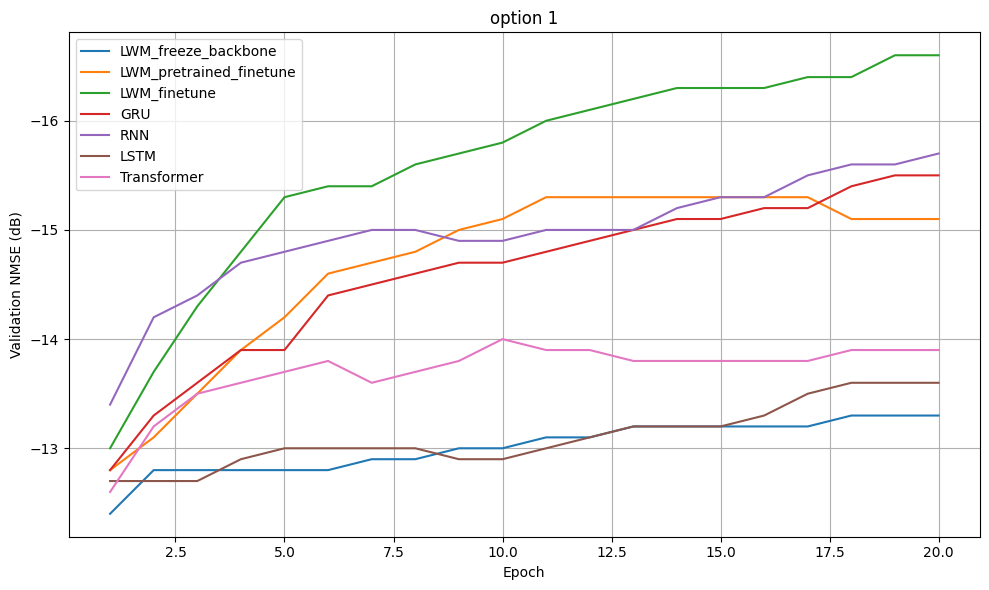

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Epochs
epochs = list(range(1, 21))

# Validation NMSE (dB) for the new training runs (manually transcribed)
val_nmse_db_new = {
    "LWM_freeze_backbone": [-12.4, -12.8, -12.8, -12.8, -12.8, -12.8, -12.9, -12.9, -13.0, -13.0,
                            -13.1, -13.1, -13.2, -13.2, -13.2, -13.2, -13.2, -13.3, -13.3, -13.3],
    "LWM_pretrained_finetune": [-12.8, -13.1, -13.5, -13.9, -14.2, -14.6, -14.7, -14.8, -15.0, -15.1,
                                -15.3, -15.3, -15.3, -15.3, -15.3, -15.3, -15.3, -15.1, -15.1, -15.1],
    "LWM_finetune": [-13.0, -13.7, -14.3, -14.8, -15.3, -15.4, -15.4, -15.6, -15.7, -15.8,
                     -16.0, -16.1, -16.2, -16.3, -16.3, -16.3, -16.4, -16.4, -16.6, -16.6],
    "GRU": [-12.8, -13.3, -13.6, -13.9, -13.9, -14.4, -14.5, -14.6, -14.7, -14.7,
            -14.8, -14.9, -15.0, -15.1, -15.1, -15.2, -15.2, -15.4, -15.5, -15.5],
    "RNN": [-13.4, -14.2, -14.4, -14.7, -14.8, -14.9, -15.0, -15.0, -14.9, -14.9,
            -15.0, -15.0, -15.0, -15.2, -15.3, -15.3, -15.5, -15.6, -15.6, -15.7],
    "LSTM": [-12.7, -12.7, -12.7, -12.9, -13.0, -13.0, -13.0, -13.0, -12.9, -12.9,
             -13.0, -13.1, -13.2, -13.2, -13.2, -13.3, -13.5, -13.6, -13.6, -13.6],
    "Transformer": [-12.6, -13.2, -13.5, -13.6, -13.7, -13.8, -13.6, -13.7, -13.8, -14.0,
                    -13.9, -13.9, -13.8, -13.8, -13.8, -13.8, -13.8, -13.9, -13.9, -13.9]
}

# Average training time per epoch (seconds)
avg_train_time_new = {
    "LWM_freeze_backbone": 70.48,
    "LWM_pretrained_finetune": 85.25,
    "LWM_finetune": 82.54,
    "GRU": 36.94,
    "RNN": 32.93,
    "LSTM": 39.59,
    "Transformer": 85.10
}

# ─────────────────────────────
# Plot 1: Validation NMSE curves (y‑axis inverted)
# ─────────────────────────────
plt.figure(figsize=(10, 6))
for model, values in val_nmse_db_new.items():
    plt.plot(epochs, values, label=model)

plt.xlabel("Epoch")
plt.ylabel("Validation NMSE (dB)")
plt.title("option 1")
plt.gca().invert_yaxis()  # lower dB (better) goes upward
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ─────────────────────────────




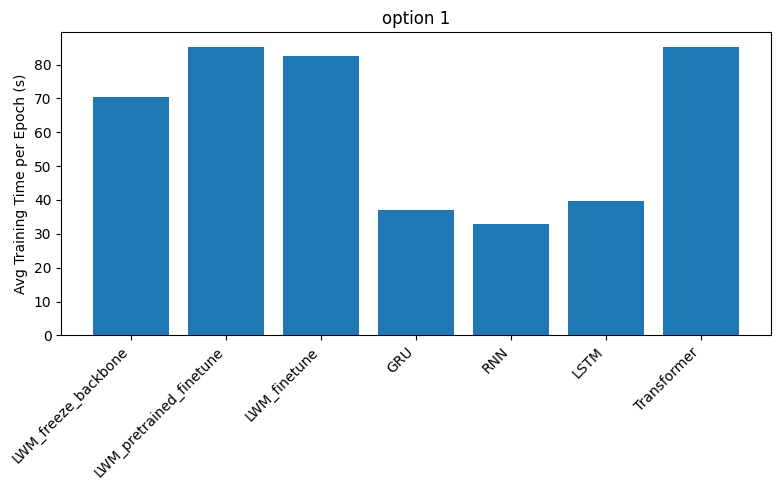

In [12]:
# Plot 2: Average training time per epoch
# ─────────────────────────────
plt.figure(figsize=(8, 5))
models = list(avg_train_time_new.keys())
times = list(avg_train_time_new.values())
plt.bar(models, times)
plt.ylabel("Avg Training Time per Epoch (s)")
plt.title("option 1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ─────────────────────────────
# Summary DataFrame
# ─────────────────────────────


In [21]:
import pandas as pd

# Manually transcribed metrics
data = {
    "model": [
        "LWM_freeze_backbone",
        "LWM_pretrained_Fine_tune",
        "LWM_Fine_tune",
        "GRU",
        "RNN",
        "LSTM",
        "Transformer"
    ],
    "best_NMSE_dB": [
        -13.305670731736381,
        -15.348194413606302,
        -16.592981129104192,
        -15.48614044357655,
        -15.737403681725255,
        -13.557530746635054,
        -13.99968065967299
    ],
    "inference_total_s": [
        36.18, 34.13, 34.73, 20.81, 19.17, 19.08, 32.39
    ],
    "inference_batch_ms": [
        34.72, 32.75, 33.33, 19.97, 18.40, 18.31, 31.08
    ],
    "inference_sample_ms": [
        1.08, 1.02, 1.04, 0.62, 0.57, 0.57, 0.97
    ],
    "trainable_params": [
        5200, 608_912, 601_744, 860_240, 292_944, 1_143_888, 707_792
    ]
}

df = pd.DataFrame(data).set_index("model")

df


=== Summary of best NMSE(dB) by model ===
LWM_freeze_backbone      : -14.555539359658
LWM_pretrained_Fine_tune : -16.013263170365
LWM_Fine_tune            : -16.145601135632
gru                      : -21.704368434366
RNN                      : -21.949823439636
LSTM                     : -21.436577475862
Transformer              : -20.532218724076

=== Inference-time summary ===
-----------------------------------------------------------------
model                    | total [s] | /batch [ms] | /sample [ms]
-----------------------------------------------------------------
LWM_freeze_backbone      |    99.32 |       27.18 |         0.85
LWM_pretrained_Fine_tune |    98.88 |       27.06 |         0.85
LWM_Fine_tune            |    99.22 |       27.15 |         0.85
gru                      |    57.67 |       15.78 |         0.49
RNN                      |    57.04 |       15.61 |         0.49
LSTM                     |    57.87 |       15.84 |         0.49
Transformer              |   1

# Option 2 : split user 2 : 1

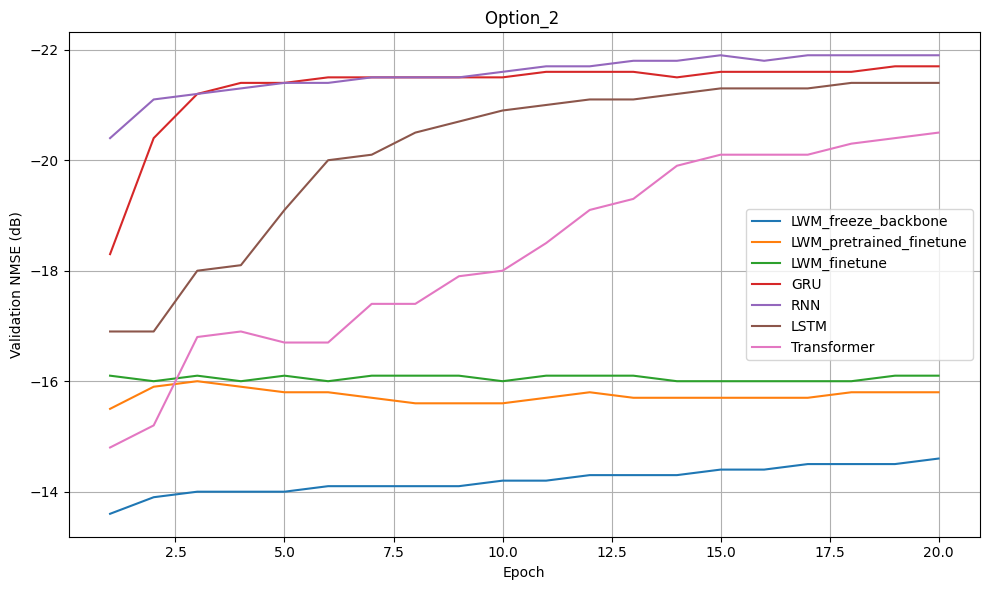

In [22]:
import matplotlib.pyplot as plt

# Epochs and NMSE values (same as user provided)
epochs = list(range(1, 21))

val_nmse_db = {
    "LWM_freeze_backbone": [-13.6, -13.9, -14.0, -14.0, -14.0, -14.1, -14.1, -14.1, -14.1, -14.2,
                            -14.2, -14.3, -14.3, -14.3, -14.4, -14.4, -14.5, -14.5, -14.5, -14.6],
    "LWM_pretrained_finetune": [-15.5, -15.9, -16.0, -15.9, -15.8, -15.8, -15.7, -15.6, -15.6, -15.6,
                                -15.7, -15.8, -15.7, -15.7, -15.7, -15.7, -15.7, -15.8, -15.8, -15.8],
    "LWM_finetune": [-16.1, -16.0, -16.1, -16.0, -16.1, -16.0, -16.1, -16.1, -16.1, -16.0,
                     -16.1, -16.1, -16.1, -16.0, -16.0, -16.0, -16.0, -16.0, -16.1, -16.1],
    "GRU": [-18.3, -20.4, -21.2, -21.4, -21.4, -21.5, -21.5, -21.5, -21.5, -21.5,
            -21.6, -21.6, -21.6, -21.5, -21.6, -21.6, -21.6, -21.6, -21.7, -21.7],
    "RNN": [-20.4, -21.1, -21.2, -21.3, -21.4, -21.4, -21.5, -21.5, -21.5, -21.6,
            -21.7, -21.7, -21.8, -21.8, -21.9, -21.8, -21.9, -21.9, -21.9, -21.9],
    "LSTM": [-16.9, -16.9, -18.0, -18.1, -19.1, -20.0, -20.1, -20.5, -20.7, -20.9,
             -21.0, -21.1, -21.1, -21.2, -21.3, -21.3, -21.3, -21.4, -21.4, -21.4],
    "Transformer": [-14.8, -15.2, -16.8, -16.9, -16.7, -16.7, -17.4, -17.4, -17.9, -18.0,
                    -18.5, -19.1, -19.3, -19.9, -20.1, -20.1, -20.1, -20.3, -20.4, -20.5]
}

# Plot with inverted y‑axis
plt.figure(figsize=(10, 6))
for model, values in val_nmse_db.items():
    plt.plot(epochs, values, label=model)

plt.xlabel("Epoch")
plt.ylabel("Validation NMSE (dB)")
plt.title("Option_2 ")
plt.gca().invert_yaxis()   # <‑‑ invert y‑axis here
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


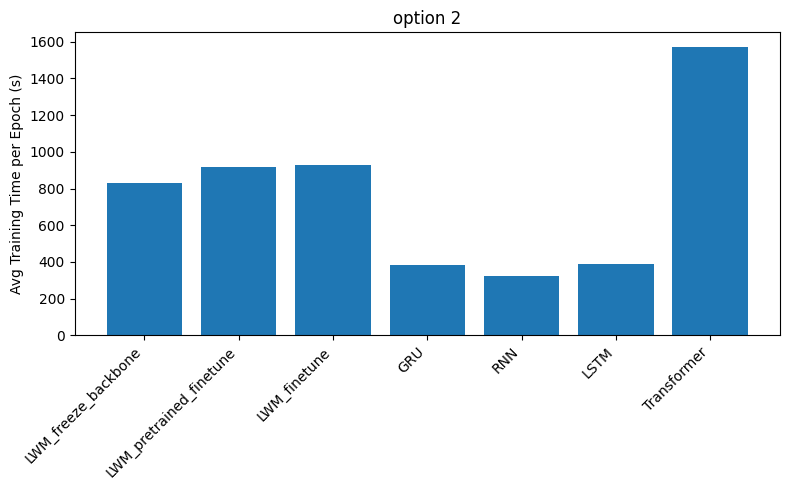

In [10]:
# Plot 2: Average training time per epoch
plt.figure(figsize=(8, 5))
models = list(avg_train_time.keys())
times = list(avg_train_time.values())
plt.bar(models, times)
plt.ylabel("Avg Training Time per Epoch (s)")
plt.title("option 2")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Display a summary DataFrame for quick reference
summary_df = pd.DataFrame({
    "Final Val NMSE (dB)": [vals[-1] for vals in val_nmse_db.values()],
    "Avg Train Time per Epoch (s)": avg_train_time.values()
}, index=val_nmse_db.keys())

In [23]:
import pandas as pd

# ── 1. Input the metrics ─────────────────────────────────────────
best_nmse = {
    "LWM_freeze_backbone":      -14.555539359657919,
    "LWM_pretrained_Fine_tune": -16.013263170365104,
    "LWM_Fine_tune":            -16.145601135632023,
    "gru":                      -21.704368434365757,
    "RNN":                      -21.949823439635763,
    "LSTM":                     -21.43657747586186,
    "Transformer":              -20.53221872407609,
}

inference_stats = {
    "LWM_freeze_backbone":      (99.32, 27.18, 0.85),   # (total s, /batch ms, /sample ms)
    "LWM_pretrained_Fine_tune": (98.88, 27.06, 0.85),
    "LWM_Fine_tune":            (99.22, 27.15, 0.85),
    "gru":                      (57.67, 15.78, 0.49),
    "RNN":                      (57.04, 15.61, 0.49),
    "LSTM":                     (57.87, 15.84, 0.49),
    "Transformer":              (135.20, 37.00, 1.16),
}

trainable_params = {
    "LWM_freeze_backbone":      5_200,
    "LWM_pretrained_Fine_tune": 608_912,
    "LWM_Fine_tune":            601_744,
    "gru":                      860_240,
    "RNN":                      292_944,
    "LSTM":                     1_143_888,
    "Transformer":              1_408_208,
}

# ── 2. Console‑output helpers (ASCII layout) ─────────────────────
def print_header(title: str):
    print(f"=== {title} ===")

def print_kv_block(d, value_fmt="{:,.6f}", value_width=0):
    """Print key/value pairs with aligned columns."""
    max_key = max(len(k) for k in d)
    if value_width <= 0:
        formatted_vals = [value_fmt.format(v) for v in d.values()]
        value_width = max(len(v) for v in formatted_vals)
    for k, v in d.items():
        print(f"{k:<{max_key}} : {value_fmt.format(v):>{value_width}}")

def print_inference_table(stats):
    """Pretty ASCII table for inference‑time metrics."""
    print("=== Inference‑time summary ===")
    header = f"{'model':<25}| {'total [s]':>8} | {'/batch [ms]':>11} | {'/sample [ms]':>12}"
    print("-" * len(header))
    print(header)
    print("-" * len(header))
    for model, (total_s, batch_ms, sample_ms) in stats.items():
        print(f"{model:<25}| {total_s:8.2f} | {batch_ms:11.2f} | {sample_ms:12.2f}")
    print("-" * len(header))

def print_param_table(p):
    """Print trainable‑parameter counts."""
    print("=== Trainable parameters per model ===")
    max_key = max(len(k) for k in p)
    print(f"{'model':<{max_key}} | params")
    print("-" * (max_key + 10))
    for k, v in p.items():
        print(f"{k:<{max_key}} | {v:,}")

# ── 3. Display results in “screenshot style” ─────────────────────
print_header("Summary of best NMSE(dB) by model")
print_kv_block(best_nmse, value_fmt="{:,.12f}")
print()  # blank line

print_inference_table(inference_stats)
print()  # blank line

print_param_table(trainable_params)

# ── 4. Build combined DataFrame and Markdown table ───────────────
df = pd.DataFrame({
    "best_NMSE_dB":          best_nmse,
    "inf_total_s":      {k: v[0] for k, v in inference_stats.items()},
    "inf_batch_ms":     {k: v[1] for k, v in inference_stats.items()},
    "inf_sample_ms":    {k: v[2] for k, v in inference_stats.items()},
    "trainable_params": trainable_params,
}).reindex(best_nmse.keys())   # preserve original order

print("\n\n=== Combined DataFrame view ===")
print(df.to_string(float_format=lambda x: f"{x:.6f}"))

print("\n\n=== Markdown Table ===")
print(df.reset_index().rename(columns={"index": "model"}).to_markdown(index=False))


=== Summary of best NMSE(dB) by model ===
LWM_freeze_backbone      : -14.555539359658
LWM_pretrained_Fine_tune : -16.013263170365
LWM_Fine_tune            : -16.145601135632
gru                      : -21.704368434366
RNN                      : -21.949823439636
LSTM                     : -21.436577475862
Transformer              : -20.532218724076

=== Inference‑time summary ===
-----------------------------------------------------------------
model                    | total [s] | /batch [ms] | /sample [ms]
-----------------------------------------------------------------
LWM_freeze_backbone      |    99.32 |       27.18 |         0.85
LWM_pretrained_Fine_tune |    98.88 |       27.06 |         0.85
LWM_Fine_tune            |    99.22 |       27.15 |         0.85
gru                      |    57.67 |       15.78 |         0.49
RNN                      |    57.04 |       15.61 |         0.49
LSTM                     |    57.87 |       15.84 |         0.49
Transformer              |   1

# Option 3

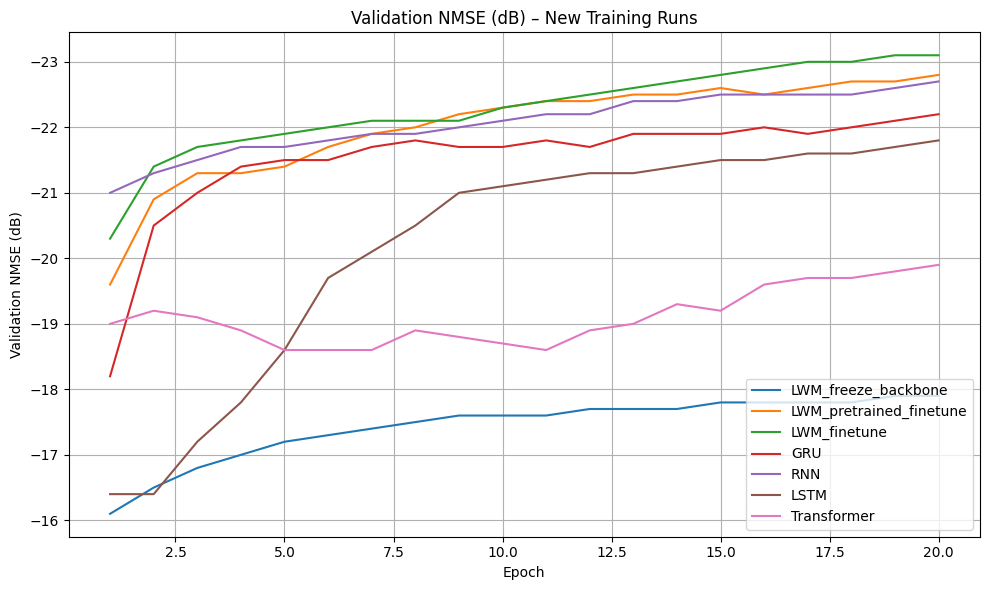

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

epochs = list(range(1, 21))

val_nmse_db = {
    "LWM_freeze_backbone": [-16.1, -16.5, -16.8, -17.0, -17.2, -17.3, -17.4, -17.5,
                            -17.6, -17.6, -17.6, -17.7, -17.7, -17.7, -17.8, -17.8,
                            -17.8, -17.8, -17.9, -17.9],
    "LWM_pretrained_finetune": [-19.6, -20.9, -21.3, -21.3, -21.4, -21.7, -21.9, -22.0,
                                -22.2, -22.3, -22.4, -22.4, -22.5, -22.5, -22.6, -22.5,
                                -22.6, -22.7, -22.7, -22.8],
    "LWM_finetune": [-20.3, -21.4, -21.7, -21.8, -21.9, -22.0, -22.1, -22.1,
                     -22.1, -22.3, -22.4, -22.5, -22.6, -22.7, -22.8, -22.9,
                     -23.0, -23.0, -23.1, -23.1],
    "GRU": [-18.2, -20.5, -21.0, -21.4, -21.5, -21.5, -21.7, -21.8,
            -21.7, -21.7, -21.8, -21.7, -21.9, -21.9, -21.9, -22.0,
            -21.9, -22.0, -22.1, -22.2],
    "RNN": [-21.0, -21.3, -21.5, -21.7, -21.7, -21.8, -21.9, -21.9,
            -22.0, -22.1, -22.2, -22.2, -22.4, -22.4, -22.5, -22.5,
            -22.5, -22.5, -22.6, -22.7],
    "LSTM": [-16.4, -16.4, -17.2, -17.8, -18.6, -19.7, -20.1, -20.5,
             -21.0, -21.1, -21.2, -21.3, -21.3, -21.4, -21.5, -21.5,
             -21.6, -21.6, -21.7, -21.8],
    "Transformer": [-19.0, -19.2, -19.1, -18.9, -18.6, -18.6, -18.6, -18.9,
                    -18.8, -18.7, -18.6, -18.9, -19.0, -19.3, -19.2, -19.6,
                    -19.7, -19.7, -19.8, -19.9],
}

avg_train_time = {
    "LWM_freeze_backbone": 797.13,
    "LWM_pretrained_finetune": 881.31,
    "LWM_finetune": 897.32,
    "GRU": 379.19,
    "RNN": 318.85,
    "LSTM": 380.68,
    "Transformer": 941.93
}

# Plot 1: Validation NMSE curves with inverted y-axis
plt.figure(figsize=(10, 6))
for model, vals in val_nmse_db.items():
    plt.plot(epochs, vals, label=model)
plt.xlabel("Epoch")
plt.ylabel("Validation NMSE (dB)")
plt.title("Validation NMSE (dB) – New Training Runs")
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




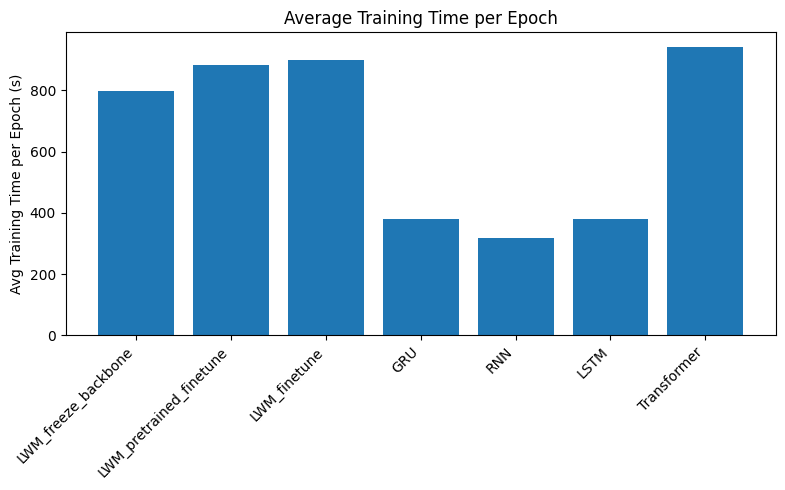

In [26]:
# Plot 2: Average training time per epoch
plt.figure(figsize=(8, 5))
plt.bar(avg_train_time.keys(), avg_train_time.values())
plt.ylabel("Avg Training Time per Epoch (s)")
plt.title("Average Training Time per Epoch")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



In [28]:
import pandas as pd

# ── 1. Updated metrics from the new screenshots ──────────────────
best_nmse = {
    "LWM_freeze_backbone":      -17.90278831553382,
    "LWM_pretrained_Fine_tune": -22.775272174287844,
    "LWM_Fine_tune":            -23.14479068327794,
    "gru":                      -22.173501171691704,
    "RNN":                      -22.71932254756395,
    "LSTM":                     -21.7848518940772,
    "Transformer":              -19.886261156445475,
}

inference_stats = {  # (total s, /batch ms, /sample ms)
    "LWM_freeze_backbone":      (126.73, 30.32, 0.95),
    "LWM_pretrained_Fine_tune": (124.83, 29.87, 0.93),
    "LWM_Fine_tune":            (131.88, 31.56, 0.99),
    "gru":                      (82.70,  19.79, 0.62),
    "RNN":                      (75.13,  17.98, 0.56),
    "LSTM":                     (76.66,  18.34, 0.57),
    "Transformer":              (125.65, 30.07, 0.94),
}

trainable_params = {
    "LWM_freeze_backbone":      5_200,
    "LWM_pretrained_Fine_tune": 608_912,
    "LWM_Fine_tune":            601_744,
    "gru":                      860_240,
    "RNN":                      292_944,
    "LSTM":                     1_143_888,
    "Transformer":              707_792,
}

# ── 2. Utility functions for console output (ASCII layout) ───────
def print_header(title: str):
    print(f"=== {title} ===")

def print_kv_block(d, value_fmt="{:,.6f}", value_width=0):
    """Align keys left and values right, emulating your screenshot layout."""
    max_key = max(len(k) for k in d)
    if value_width == 0:
        formatted_vals = [value_fmt.format(v) for v in d.values()]
        value_width = max(len(v) for v in formatted_vals)
    for k, v in d.items():
        print(f"{k:<{max_key}} : {value_fmt.format(v):>{value_width}}")

def print_inference_table(stats):
    print("=== Inference‑time summary ===")
    header = f"{'model':<25}| {'total [s]':>8} | {'/batch [ms]':>11} | {'/sample [ms]':>12}"
    print("-" * len(header))
    print(header)
    print("-" * len(header))
    for model, (total_s, batch_ms, sample_ms) in stats.items():
        print(f"{model:<25}| {total_s:8.2f} | {batch_ms:11.2f} | {sample_ms:12.2f}")
    print("-" * len(header))

def print_param_table(p):
    print("=== Trainable parameters per model ===")
    max_key = max(len(k) for k in p)
    print(f"{'model':<{max_key}} | params")
    print("-" * (max_key + 10))
    for k, v in p.items():
        print(f"{k:<{max_key}} | {v:,}")

# ── 3. “Screenshot‑style” console printout ───────────────────────
print_header("Summary of best NMSE(dB) by model")
print_kv_block(best_nmse, value_fmt="{:,.12f}")
print()                                      # blank line

print_inference_table(inference_stats)
print()                                      # blank line

print_param_table(trainable_params)

# ── 4. Combined DataFrame & Markdown export (optional) ───────────
df = pd.DataFrame({
    "best_NMSE_dB":          best_nmse,
    "inf_total_s":      {k: v[0] for k, v in inference_stats.items()},
    "inf_batch_ms":     {k: v[1] for k, v in inference_stats.items()},
    "inf_sample_ms":    {k: v[2] for k, v in inference_stats.items()},
    "trainable_params": trainable_params,
}).reindex(best_nmse.keys())  # keep original order

print("\n\n=== Combined DataFrame view ===")
print(df.to_string(float_format=lambda x: f"{x:.6f}"))

print("\n\n=== Markdown Table ===")
print(df.reset_index().rename(columns={"index": "model"}).to_markdown(index=False))


=== Summary of best NMSE(dB) by model ===
LWM_freeze_backbone      : -17.902788315534
LWM_pretrained_Fine_tune : -22.775272174288
LWM_Fine_tune            : -23.144790683278
gru                      : -22.173501171692
RNN                      : -22.719322547564
LSTM                     : -21.784851894077
Transformer              : -19.886261156445

=== Inference‑time summary ===
-----------------------------------------------------------------
model                    | total [s] | /batch [ms] | /sample [ms]
-----------------------------------------------------------------
LWM_freeze_backbone      |   126.73 |       30.32 |         0.95
LWM_pretrained_Fine_tune |   124.83 |       29.87 |         0.93
LWM_Fine_tune            |   131.88 |       31.56 |         0.99
gru                      |    82.70 |       19.79 |         0.62
RNN                      |    75.13 |       17.98 |         0.56
LSTM                     |    76.66 |       18.34 |         0.57
Transformer              |   1